In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Install torch_geometric if it's not already installed
try:
    import torch_geometric
except ImportError:
    !pip install torch_geometric

from torch.optim import Adam
from torch_geometric.nn import GATConv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.1 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving real graph.pt to real graph (1).pt


In [3]:
graph = torch.load(
    "/content/real graph.pt",
    weights_only=False,
    map_location="cpu"
)

In [4]:
print(type(graph))
print(graph)

print("\nNode Features:", graph.x.shape)
print("Edges:", graph.edge_index.shape)
print("Labels:", graph.y.shape)

print("\nTraining Nodes:", graph.train_mask.sum().item())
print("Validation Nodes:", graph.val_mask.sum().item())
print("Testing Nodes:", graph.test_mask.sum().item())

<class 'torch_geometric.data.data.Data'>
Data(x=[1000, 152], edge_index=[2, 8054], y=[1000], edge_weight=[8054], train_mask=[1000], val_mask=[1000], test_mask=[1000])

Node Features: torch.Size([1000, 152])
Edges: torch.Size([2, 8054])
Labels: torch.Size([1000])

Training Nodes: 700
Validation Nodes: 150
Testing Nodes: 150


In [5]:
class OriginalGAT(nn.Module):

    def __init__(self, input_dim, hidden_dim=32, num_classes=3):
        super().__init__()

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=4,
            dropout=0.3
        )

        self.gat2 = GATConv(
            hidden_dim * 4,
            hidden_dim,
            heads=1,
            dropout=0.3
        )

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.gat1(x, edge_index)
        x = F.elu(x)

        x = self.gat2(x, edge_index)
        x = F.elu(x)

        x = self.classifier(x)

        return x

In [6]:
model = OriginalGAT(
    input_dim=graph.x.shape[1],
    hidden_dim=32,
    num_classes=3
)

print(model)

OriginalGAT(
  (gat1): GATConv(152, 32, heads=4)
  (gat2): GATConv(128, 32, heads=1)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)


In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

model = model.to(device)
graph = graph.to(device)

Using: cpu


In [8]:
class_counts = torch.bincount(graph.y[graph.train_mask])

weights = 1.0 / class_counts.float()

weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(
    weight=weights.to(device)
)

print(weights)

tensor([0.4000, 0.2000, 0.4000])


In [9]:
optimizer = Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0005
)


In [10]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(graph)

    loss = criterion(
        out[graph.train_mask],
        graph.y[graph.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [11]:
@torch.no_grad()
def validate():

    model.eval()

    out = model(graph)

    pred = out.argmax(dim=1)

    correct = (
        pred[graph.val_mask]
        ==
        graph.y[graph.val_mask]
    ).sum()

    accuracy = (
        correct /
        graph.val_mask.sum()
    )

    return accuracy.item()

In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

num_epochs = 300

best_val_acc = 0

train_losses = []
validation_accuracy = []

for epoch in range(1, num_epochs + 1):

    loss = train()

    val_acc = validate()

    train_losses.append(loss)
    validation_accuracy.append(val_acc)


    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/New_Real_GAT.pth"
        )


    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Validation Accuracy: {val_acc:.4f}"
        )


print("Best Validation Accuracy:", best_val_acc)

Mounted at /content/drive
Epoch 010 | Loss: 0.9683 | Validation Accuracy: 0.5333
Epoch 020 | Loss: 0.7953 | Validation Accuracy: 0.6133
Epoch 030 | Loss: 0.6406 | Validation Accuracy: 0.6533
Epoch 040 | Loss: 0.5320 | Validation Accuracy: 0.6867
Epoch 050 | Loss: 0.4634 | Validation Accuracy: 0.7067
Epoch 060 | Loss: 0.4210 | Validation Accuracy: 0.7000
Epoch 070 | Loss: 0.4015 | Validation Accuracy: 0.7133
Epoch 080 | Loss: 0.3863 | Validation Accuracy: 0.7200
Epoch 090 | Loss: 0.3542 | Validation Accuracy: 0.7267
Epoch 100 | Loss: 0.3137 | Validation Accuracy: 0.7067
Epoch 110 | Loss: 0.3288 | Validation Accuracy: 0.7200
Epoch 120 | Loss: 0.3114 | Validation Accuracy: 0.7267
Epoch 130 | Loss: 0.2980 | Validation Accuracy: 0.7267
Epoch 140 | Loss: 0.2745 | Validation Accuracy: 0.7267
Epoch 150 | Loss: 0.2757 | Validation Accuracy: 0.7333
Epoch 160 | Loss: 0.2636 | Validation Accuracy: 0.7400
Epoch 170 | Loss: 0.2519 | Validation Accuracy: 0.7467
Epoch 180 | Loss: 0.2392 | Validation A

In [14]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/New_Real_GAT.pth"
    )
)

model.eval()

print("Best model loaded")

Best model loaded


In [15]:
@torch.no_grad()
def test():

    model.eval()

    out = model(graph)

    pred = out.argmax(dim=1)

    correct = (
        pred[graph.test_mask]
        ==
        graph.y[graph.test_mask]
    ).sum()

    accuracy = (
        correct /
        graph.test_mask.sum()
    )

    return accuracy.item(), pred

In [16]:
test_accuracy, predictions = test()

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7733333110809326


In [17]:
torch.save(
    model.state_dict(),
    "/content/Original_GAT_New Real.pth"
)

print("Original GAT model saved successfully!")

Original GAT model saved successfully!


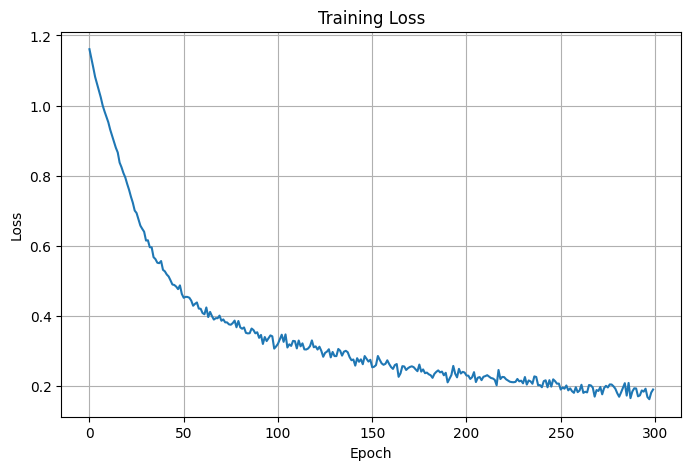

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

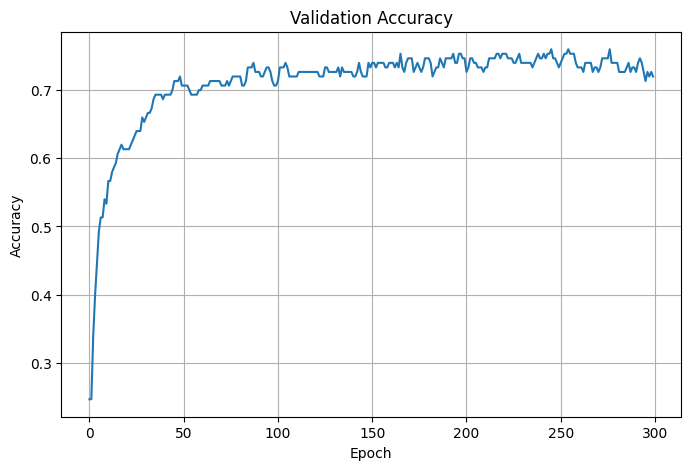

In [19]:
plt.figure(figsize=(8,5))
plt.plot(validation_accuracy)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [20]:
print(model)

OriginalGAT(
  (gat1): GATConv(152, 32, heads=4)
  (gat2): GATConv(128, 32, heads=1)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Original_GAT_New Real.pth"
)

print("Model saved to Google Drive successfully!")

Model saved to Google Drive successfully!


In [23]:
import os

print(os.path.exists("/content/drive/MyDrive/Original_GAT_New Real.pth"))

True
